# Notebook B: Natural-Distribution Validation and Multi-Horizon Prediction

This notebook covers two experiments using the 75GB day-level extraction (full grid preserved per day, with genuine calendar dates, originally built for the abandoned GNN approach and repurposed here).

**Experiment 2: Natural-Distribution Validation**
The original validation set used the same 11% non-event retention as training. This experiment builds a genuine natural-distribution validation set from 2023 only (the correct validation year), then re-evaluates the already-trained first-set models against it, to see how their reported performance shifts when validation reflects the true class balance.

**Experiment 4: Multi-Horizon Prediction with Epoch-Rotation Sampling**
Predicts dust events at three horizons matching actual label granularity: day+0, day+1, day+2, using one shared LSTM+CMA encoder with three output heads. Class imbalance is handled without any permanent data deletion: every epoch, all positive samples are used, plus a freshly drawn random subset of negative samples, so across many epochs the model sees the full negative pool in rotation rather than a single fixed, permanently reduced sample. Trained with Focal Loss, tested here in the severely imbalanced regime it was actually designed for, unlike the first experiment set where it was tested on already-balanced data and showed no benefit.

## 1. Imports

In [1]:
import numpy as np
import os
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, IterableDataset, DataLoader

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    average_precision_score, accuracy_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, log_loss
)

import matplotlib.pyplot as plt

!pip install wandb -q
import wandb
import joblib

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

N_ATM_VARS = 7
N_SURF_VARS = 7

SAVE_DIR = '/kaggle/working/notebook_b'
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(f'{SAVE_DIR}/models', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/figures', exist_ok=True)
os.makedirs(f'{SAVE_DIR}/data', exist_ok=True)

wandb.login()

DATA_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    npz_files = [f for f in files if f.startswith('gnn_batch_')]
    if npz_files:
        DATA_DIR = root
        break

batch_files = sorted([f for f in os.listdir(DATA_DIR) if f.startswith('gnn_batch_')])
print(f"Found {len(batch_files)} day-level batch files")

SM_MIN, SM_MAX = 0.0, 1.0
VWC_MIN, VWC_MAX = 0.0, 15.0
LAT_MIN, LAT_MAX = 10.0, 25.0
LON_MIN, LON_MAX = -18.0, 25.0
GRID_RES = 0.25

Device: cuda


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: idaraessien67 (idaraessien67-african-leadership-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Found 124 day-level batch files


## Shared Model Components

Same architecture family as the first experiment set: LSTM atmospheric encoder, surface MLP encoder, bidirectional cross-modal attention. Reused here for both experiments.

In [2]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_dim=7, embed_dim=256, hidden_dim=128, num_layers=2, dropout=0.24):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.projection = nn.Linear(hidden_dim * 2, embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers * 2, batch_size, self.hidden_dim, device=x.device)
        c0 = torch.zeros(self.num_layers * 2, batch_size, self.hidden_dim, device=x.device)
        _, (h_n, _) = self.lstm(x, (h0, c0))
        return self.norm(self.projection(self.dropout(torch.cat([h_n[-2], h_n[-1]], dim=-1))))


class SurfaceEncoder(nn.Module):
    def __init__(self, input_dim=7, embed_dim=256, dropout=0.24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, embed_dim), nn.LayerNorm(embed_dim))

    def forward(self, x):
        return self.net(x)


class CrossModalAttention(nn.Module):
    def __init__(self, embed_dim=256, num_heads=8, dropout=0.1):
        super().__init__()
        self.attn_s2a = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.attn_a2s = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_s = nn.LayerNorm(embed_dim)
        self.norm_a = nn.LayerNorm(embed_dim)

    def forward(self, surf_emb, atm_emb):
        s, a = surf_emb.unsqueeze(1), atm_emb.unsqueeze(1)
        s_out, _ = self.attn_s2a(s, a, a)
        a_out, _ = self.attn_a2s(a, s, s)
        return self.norm_s(s_out.squeeze(1) + surf_emb), self.norm_a(a_out.squeeze(1) + atm_emb)


class PredictionHead(nn.Module):
    def __init__(self, input_dim=512, dropout=0.54):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1))

    def forward(self, x):
        return self.net(x).squeeze(-1)


class DustModel(nn.Module):
    def __init__(self, embed_dim=256, dropout=0.24, num_heads=8):
        super().__init__()
        self.atm_encoder = LSTMEncoder(input_dim=N_ATM_VARS, embed_dim=embed_dim, dropout=dropout)
        self.surf_encoder = SurfaceEncoder(input_dim=7, embed_dim=embed_dim, dropout=dropout)
        self.cross_attn = CrossModalAttention(embed_dim=embed_dim, num_heads=num_heads)
        self.head = PredictionHead(input_dim=embed_dim * 2, dropout=0.54)

    def forward(self, atm, surf):
        a = self.atm_encoder(atm)
        s = self.surf_encoder(surf)
        s, a = self.cross_attn(s, a)
        return self.head(torch.cat([s, a], dim=-1))


print("Shared components defined")

Shared components defined


## Experiment 2: Build Natural-Distribution 2023 Validation Set

Reads only 2023 days from the day-level extraction, flattens every valid grid cell (no subsampling at all, since one year of data is small enough to hold fully in memory), producing a true natural-distribution validation set.

In [3]:
X_atm_val_list = []
X_surf_val_list = []
y_val_list = []
row_col_list = []
date_list = []

t0 = time.time()

for bf in batch_files:
    data = np.load(f'{DATA_DIR}/{bf}')
    dates_arr = data['dates']
    years_in_batch = np.array([int(str(d)[:4]) for d in dates_arr])

    if not (years_in_batch == 2023).any():
        data.close()
        continue

    atm_grids_all = data['atm_grids']
    sm_grids_all = data['sm_grids']
    vwc_grids_all = data['vwc_grids']
    prev_aod_grids_all = data['prev_aod_grids']
    label_grids_all = data['label_grids']
    valid_masks_all = data['valid_masks']

    for i in range(len(dates_arr)):
        if years_in_batch[i] != 2023:
            continue

        mask_flat = valid_masks_all[i].flatten().astype(bool)
        sm_flat = sm_grids_all[i].flatten()
        vwc_flat = vwc_grids_all[i].flatten()

        smap_valid = (sm_flat >= SM_MIN) & (sm_flat <= SM_MAX) & (vwc_flat >= VWC_MIN) & (vwc_flat <= VWC_MAX)
        combined_valid = mask_flat & smap_valid
        valid_ids = np.where(combined_valid)[0]

        if len(valid_ids) == 0:
            continue

        n_rows, n_cols = label_grids_all[i].shape
        atm_flat = atm_grids_all[i].reshape(n_rows * n_cols, 72, 7)
        prev_aod_flat = prev_aod_grids_all[i].flatten()
        label_flat = label_grids_all[i].flatten()

        X_atm_val_list.append(atm_flat[valid_ids])
        X_surf_val_list.append(np.stack([sm_flat[valid_ids], vwc_flat[valid_ids], prev_aod_flat[valid_ids]], axis=1))
        y_val_list.append(label_flat[valid_ids])

        for vid in valid_ids:
            row_col_list.append((vid // n_cols, vid % n_cols))
            date_list.append(str(dates_arr[i]))

    data.close()

X_atm_val_natural = np.concatenate(X_atm_val_list, axis=0).astype(np.float32)
X_surf_val_natural_3feat = np.concatenate(X_surf_val_list, axis=0).astype(np.float32)
y_val_natural = np.concatenate(y_val_list, axis=0).astype(np.float32)

del X_atm_val_list, X_surf_val_list, y_val_list

print(f"Built in {time.time()-t0:.1f}s")
print(f"Natural 2023 validation set: {len(y_val_natural):,} samples, dust rate: {y_val_natural.mean()*100:.2f}%")

Built in 75.0s
Natural 2023 validation set: 1,458,327 samples, dust rate: 4.01%


## Experiment 2: Rebuild Full 7-Feature Surface Array and Normalize

Adds lat, lon, month_sin, month_cos back per cell, then applies the original StandardScaler fitted during the first experiment set.

In [4]:
def rebuild_full_surface(X_surf_3feat, row_col_list, dates_list):
    lats = np.array([LAT_MAX - r * GRID_RES for r, c in row_col_list])
    lons = np.array([LON_MIN + c * GRID_RES for r, c in row_col_list])
    months = np.array([int(d[5:7]) for d in dates_list])
    month_sin = np.sin(2 * np.pi * months / 12)
    month_cos = np.cos(2 * np.pi * months / 12)
    return np.concatenate([
        X_surf_3feat, lats.reshape(-1, 1), lons.reshape(-1, 1),
        month_sin.reshape(-1, 1), month_cos.reshape(-1, 1)
    ], axis=1).astype(np.float32)


X_surf_val_full = rebuild_full_surface(X_surf_val_natural_3feat, row_col_list, date_list)

atm_scaler = joblib.load('/kaggle/input/datasets/valour256/saheldust-cma-scalers/atm_scaler.pkl')
surf_scaler = joblib.load('/kaggle/input/datasets/valour256/saheldust-cma-scalers/surf_scaler.pkl')

X_atm_val_natural_norm = atm_scaler.transform(
    X_atm_val_natural.reshape(-1, 7)
).reshape(X_atm_val_natural.shape).astype(np.float32)

X_surf_val_natural_norm = surf_scaler.transform(X_surf_val_full).astype(np.float32)

print(f"Normalized atm shape: {X_atm_val_natural_norm.shape}")
print(f"Normalized surf shape: {X_surf_val_natural_norm.shape}")

Normalized atm shape: (1458327, 72, 7)
Normalized surf shape: (1458327, 7)


## Load Best First-Set Model and Evaluate

In [5]:
best_model = DustModel(embed_dim=256, dropout=0.24, num_heads=8).to(device)
state_dict = torch.load('/kaggle/input/datasets/valour256/lstm-cma-model/lstm___cma_v2.pt', map_location=device)
best_model.load_state_dict(state_dict)
best_model.eval()
print("Model loaded")

val_dataset_natural = torch.utils.data.TensorDataset(
    torch.tensor(X_atm_val_natural_norm, dtype=torch.float32),
    torch.tensor(X_surf_val_natural_norm, dtype=torch.float32),
    torch.tensor(y_val_natural, dtype=torch.float32)
)
val_loader_natural = DataLoader(val_dataset_natural, batch_size=512, shuffle=False)

vp, vt = [], []
with torch.no_grad():
    for atm, surf, y in val_loader_natural:
        atm, surf = atm.to(device), surf.to(device)
        logits = best_model(atm, surf)
        vp.extend(torch.sigmoid(logits).cpu().numpy())
        vt.extend(y.numpy())

vp = np.array(vp)
vt = np.array(vt)
vd = (vp > 0.5).astype(int)

print("Natural-Distribution Validation Results (2023, true dust rate):")
print(f"  Precision:    {precision_score(vt, vd, zero_division=0):.4f}")
print(f"  Recall:       {recall_score(vt, vd, zero_division=0):.4f}")
print(f"  F1:           {f1_score(vt, vd, zero_division=0):.4f}")
print(f"  Accuracy:     {accuracy_score(vt, vd):.4f}")
print(f"  ROC-AUC:      {roc_auc_score(vt, vp):.4f}")
print(f"  PR-AUC:       {average_precision_score(vt, vp):.4f}")

print(f"\nOriginal Subsampled-Distribution Validation Results (first experiment set):")
print(f"  Precision: 0.3734 | Recall: 0.4798 | F1: 0.4200 | ROC-AUC: 0.8577")
print(f"\nDust rate, natural: {y_val_natural.mean()*100:.2f}% vs subsampled: ~50%")

results_exp2 = {
    'natural_precision': precision_score(vt, vd, zero_division=0),
    'natural_recall': recall_score(vt, vd, zero_division=0),
    'natural_f1': f1_score(vt, vd, zero_division=0),
    'natural_auc': roc_auc_score(vt, vp),
    'natural_prauc': average_precision_score(vt, vp),
}

with open(f'{SAVE_DIR}/exp2_natural_validation_results.pkl', 'wb') as f:
    pickle.dump(results_exp2, f)
print(f"\nSaved to {SAVE_DIR}/exp2_natural_validation_results.pkl")

Model loaded
Natural-Distribution Validation Results (2023, true dust rate):
  Precision:    0.1598
  Recall:       0.7214
  F1:           0.2617
  Accuracy:     0.8368
  ROC-AUC:      0.8709
  PR-AUC:       0.3011

Original Subsampled-Distribution Validation Results (first experiment set):
  Precision: 0.3734 | Recall: 0.4798 | F1: 0.4200 | ROC-AUC: 0.8577

Dust rate, natural: 4.01% vs subsampled: ~50%

Saved to /kaggle/working/notebook_b/exp2_natural_validation_results.pkl


## Experiment 4: Build Label Lookup for Multi-Horizon Targets

For each valid cell on day D, we need dust event labels on day D, D+1, and D+2 at the same grid location. Rather than re-scanning the full atmospheric data to find these, a lightweight lookup table is built first: only the small label grids (not the 72-hour atmospheric arrays) are loaded for every day across the full 10 years, keyed by date string. This table is small enough to hold entirely in memory (roughly 37MB) and lets the training data builder look up any day's grid instantly.

In [6]:
label_grid_by_date = {}

t0 = time.time()
for bf in batch_files:
    data = np.load(f'{DATA_DIR}/{bf}')
    dates_arr = data['dates']
    label_grids_all = data['label_grids']

    for i in range(len(dates_arr)):
        label_grid_by_date[str(dates_arr[i])] = label_grids_all[i].copy()

    data.close()

print(f"Label lookup built in {time.time()-t0:.1f}s")
print(f"Total days indexed: {len(label_grid_by_date)}")

Label lookup built in 0.9s
Total days indexed: 3653


## Experiment 4: Streaming Multi-Horizon Dataset with Epoch-Rotation Sampling

Each epoch, this dataset streams fresh from the compressed day-level batch files (never permanently modifying the source). Every positive sample (day+0 dust event) is always included. Negative samples are included with a random per-epoch keep probability, reseeded each epoch, so different negatives are seen across different epochs, giving the model exposure to the full negative pool in rotation rather than one fixed, permanently reduced subset. For each kept sample, day+1 and day+2 labels are looked up from the pre-built label table; samples where either horizon falls outside the extracted date range are skipped (only affects the last 2 days of the dataset).

In [7]:
import numpy as np
import torch
import math
from datetime import datetime, timedelta
from torch.utils.data import IterableDataset, DataLoader

class MultiHorizonStreamingDataset(IterableDataset):
    """
    Streams multi-horizon weather data dynamically using NumPy array vectorization 
    for fast feature compilation. Retains samples mapping to positive dust events 
    in any prediction horizon. Distributes workloads across multiple PyTorch workers.
    """
    def __init__(self, batch_file_list, data_dir, years_filter, label_lookup,
                 atm_scaler, surf_scaler, epoch_seed=0, negative_keep_prob=0.25):
        self.batch_file_list = batch_file_list
        self.data_dir = data_dir
        self.years_filter = years_filter
        self.label_lookup = label_lookup
        self.atm_scaler = atm_scaler
        self.surf_scaler = surf_scaler
        self.epoch_seed = epoch_seed
        self.negative_keep_prob = negative_keep_prob

    def __iter__(self):
        worker_info = torch.utils.data.get_worker_info()
        
        # Partition the dataset across workers if DataLoader uses multiple threads
        if worker_info is None:
            worker_files = self.batch_file_list
            rng_seed = self.epoch_seed
        else:
            per_worker = int(math.ceil(len(self.batch_file_list) / float(worker_info.num_workers)))
            worker_id = worker_info.id
            start = worker_id * per_worker
            end = min(start + per_worker, len(self.batch_file_list))
            worker_files = self.batch_file_list[start:end]
            rng_seed = self.epoch_seed + worker_id

        rng = np.random.RandomState(rng_seed)

        for bf in worker_files:
            data = np.load(f'{self.data_dir}/{bf}')
            dates_arr = data['dates']
            atm_grids_all = data['atm_grids']
            sm_grids_all = data['sm_grids']
            vwc_grids_all = data['vwc_grids']
            prev_aod_grids_all = data['prev_aod_grids']
            label_grids_all = data['label_grids']
            valid_masks_all = data['valid_masks']

            for i in range(len(dates_arr)):
                date_str = str(dates_arr[i])
                year = int(date_str[:4])
                if year not in self.years_filter:
                    continue

                current_date = datetime.strptime(date_str, '%Y-%m-%d')
                date_plus1 = (current_date + timedelta(days=1)).strftime('%Y-%m-%d')
                date_plus2 = (current_date + timedelta(days=2)).strftime('%Y-%m-%d')

                if date_plus1 not in self.label_lookup or date_plus2 not in self.label_lookup:
                    continue

                mask_flat = valid_masks_all[i].flatten().astype(bool)
                sm_flat = sm_grids_all[i].flatten()
                vwc_flat = vwc_grids_all[i].flatten()

                smap_valid = (sm_flat >= 0.0) & (sm_flat <= 1.0) & (vwc_flat >= 0.0) & (vwc_flat <= 15.0)
                combined_valid = mask_flat & smap_valid
                valid_ids = np.where(combined_valid)[0]

                if len(valid_ids) == 0:
                    continue

                n_rows, n_cols = label_grids_all[i].shape
                label_day0_flat = label_grids_all[i].flatten()
                label_day1_flat = self.label_lookup[date_plus1].flatten()
                label_day2_flat = self.label_lookup[date_plus2].flatten()
                
                atm_flat = atm_grids_all[i].reshape(n_rows * n_cols, 72, 7)
                prev_aod_flat = prev_aod_grids_all[i].flatten()

                # Vectorized sampling evaluation
                y0_all = label_day0_flat[valid_ids]
                y1_all = label_day1_flat[valid_ids]
                y2_all = label_day2_flat[valid_ids]

                is_positive = (y0_all == 1) | (y1_all == 1) | (y2_all == 1)
                random_probs = rng.random(len(valid_ids))
                keep_mask = is_positive | (random_probs <= self.negative_keep_prob)
                
                kept_ids = valid_ids[keep_mask]
                
                if len(kept_ids) == 0:
                    continue

                # Vectorized feature stack generation
                rows = kept_ids // n_cols
                cols = kept_ids % n_cols
                lats = 25.0 - rows * 0.25
                lons = -18.0 + cols * 0.25
                
                month = current_date.month
                month_sin = np.full(len(kept_ids), np.sin(2 * np.pi * month / 12), dtype=np.float32)
                month_cos = np.full(len(kept_ids), np.cos(2 * np.pi * month / 12), dtype=np.float32)

                sm_kept = sm_flat[kept_ids]
                vwc_kept = vwc_flat[kept_ids]
                prev_aod_kept = prev_aod_flat[kept_ids]

                surf_raw = np.column_stack([sm_kept, vwc_kept, prev_aod_kept, lats, lons, month_sin, month_cos]).astype(np.float32)
                atm_raw = atm_flat[kept_ids]
                
                y0_kept = y0_all[keep_mask]
                y1_kept = y1_all[keep_mask]
                y2_kept = y2_all[keep_mask]

                # Matrix normalization and safeguard deployment
                atm_norm = self.atm_scaler.transform(atm_raw.reshape(-1, 7)).reshape(-1, 72, 7).astype(np.float32)
                surf_norm = self.surf_scaler.transform(surf_raw).astype(np.float32)

                atm_norm = np.nan_to_num(atm_norm, nan=0.0, posinf=0.0, neginf=0.0)
                surf_norm = np.nan_to_num(surf_norm, nan=0.0, posinf=0.0, neginf=0.0)

                for idx in range(len(kept_ids)):
                    yield (
                        torch.tensor(atm_norm[idx], dtype=torch.float32),
                        torch.tensor(surf_norm[idx], dtype=torch.float32),
                        torch.tensor([y0_kept[idx], y1_kept[idx], y2_kept[idx]], dtype=torch.float32)
                    )

            data.close()
            del atm_grids_all, sm_grids_all, vwc_grids_all, prev_aod_grids_all, label_grids_all, valid_masks_all

## Experiment 4: Multi-Horizon Model

Same LSTM+CMA encoder as the base architecture, three lightweight output heads reading from the same shared embedding, one per horizon.

In [8]:
class MultiHorizonDustModel(nn.Module):
    def __init__(self, embed_dim=256, dropout=0.24, num_heads=8):
        super().__init__()
        self.atm_encoder = LSTMEncoder(input_dim=N_ATM_VARS, embed_dim=embed_dim, dropout=dropout)
        self.surf_encoder = SurfaceEncoder(input_dim=7, embed_dim=embed_dim, dropout=dropout)
        self.cross_attn = CrossModalAttention(embed_dim=embed_dim, num_heads=num_heads)

        # Helper function to build decoupled, identical heads
        def build_head():
            return nn.Sequential(
                nn.Linear(embed_dim * 2, 256), nn.ReLU(), nn.Dropout(0.54),
                nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.54),
                nn.Linear(128, 1)
            )

        self.head_day0 = build_head()
        self.head_day1 = build_head()
        self.head_day2 = build_head()

    def forward(self, atm, surf):
        a = self.atm_encoder(atm)
        s = self.surf_encoder(surf)
        s, a = self.cross_attn(s, a)
        
        # Branching immediately after fusion instead of sharing dense layers
        fused = torch.cat([s, a], dim=-1)

        out0 = self.head_day0(fused).squeeze(-1)
        out1 = self.head_day1(fused).squeeze(-1)
        out2 = self.head_day2(fused).squeeze(-1)

        return torch.stack([out0, out1, out2], dim=1)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (alpha_t * (1 - p_t) ** self.gamma * bce).mean()

print("Classes both defined")

Classes both defined


## Experiment 4: Training Function

Includes checkpointing after every epoch (safe against Kaggle session interruption), per-epoch negative resampling via a new random seed each epoch, and WandB logging.

In [9]:
import os
import torch.nn.functional as F

def train_multi_horizon_optimized(model, batch_split_map, DATA_DIR, label_grid_by_date,
                                  atm_scaler, surf_scaler, val_loader,
                                  epochs=15, lr=0.0001, weight_decay=0.003,
                                  checkpoint_path=None, wandb_project="saheldust-multihorizon"):
    
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)
    criterion = FocalLoss(alpha=0.65, gamma=2.0)
    
    # Initialize the gradient scaler for Automatic Mixed Precision
    scaler = torch.cuda.amp.GradScaler()

    best_f1_avg = 0
    best_state = None
    start_epoch = 1
    history = {'train_loss': [], 'val_f1_day0': [], 'val_f1_day1': [], 'val_f1_day2': []}

    if checkpoint_path and os.path.exists(checkpoint_path):
        ckpt = torch.load(checkpoint_path)
        model.load_state_dict(ckpt['model_state'])
        optimiser.load_state_dict(ckpt['optimiser_state'])
        start_epoch = ckpt['epoch'] + 1
        best_f1_avg = ckpt['best_f1_avg']
        history = ckpt['history']
        print(f"Resumed from epoch {start_epoch - 1}, best avg F1: {best_f1_avg:.4f}")

    run = wandb.init(
        entity="idaraessien67-african-leadership-university",
        project=wandb_project,
        name="MultiHorizon_LSTM_CMA_v2_Optimized",
        config={"lr": lr, "weight_decay": weight_decay, "epochs": epochs},
        reinit="finish_previous"
    )

    for epoch in range(start_epoch, epochs + 1):
        train_dataset = MultiHorizonStreamingDataset(
            batch_split_map['train'], DATA_DIR, {2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022},
            label_grid_by_date, atm_scaler, surf_scaler,
            epoch_seed=epoch, negative_keep_prob=0.25
        )
        
        # DataLoader optimized for streaming latency reduction
        train_loader = DataLoader(
            train_dataset, 
            batch_size=512, 
            num_workers=4, 
            pin_memory=True, 
            prefetch_factor=2
        )

        print(f"\nepoch {epoch}")
        model.train()
        train_loss = 0
        n_batches = 0
        skipped_batches = 0
        
        for atm, surf, y in train_loader:
            # Transfer directly utilizing page-locked memory
            atm = atm.to(device, non_blocking=True)
            surf = surf.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            
            optimiser.zero_grad(set_to_none=True)
            
            # Forward pass encapsulated in the autocast context manager
            with torch.cuda.amp.autocast():
                logits = model(atm, surf)
                loss = criterion(logits, y)

            if torch.isnan(loss).any() or torch.isinf(loss).any():
                skipped_batches += 1
                continue

            if loss.item() > 5.0:
                print(f"WARNING: high loss batch detected: {loss.item():.4f} at epoch {epoch}, batch {n_batches}")

            # Scale and unscale routines around clipping requirements
            scaler.scale(loss).backward()
            scaler.unscale_(optimiser)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            
            scaler.step(optimiser)
            scaler.update()
            
            train_loss += loss.item()
            n_batches += 1

            if n_batches % 500 == 0:
                print(f"Epoch {epoch}, batch {n_batches}, running avg loss: {train_loss/n_batches:.4f}")

        train_loss /= max(n_batches, 1)
        if skipped_batches > 0:
            print(f"Skipped {skipped_batches} NaN/Inf batches this epoch")

        print(f"  Epoch {epoch} training done, {n_batches} total batches. Running validation...")

        model.eval()
        vp0, vp1, vp2, vt0, vt1, vt2 = [], [], [], [], [], []
        with torch.no_grad():
            for atm, surf, y in val_loader:
                atm = atm.to(device, non_blocking=True)
                surf = surf.to(device, non_blocking=True)
                
                with torch.cuda.amp.autocast():
                    logits = model(atm, surf)
                
                probs = torch.sigmoid(logits).cpu().numpy()
                y_np = y.numpy()
                vp0.extend(probs[:, 0]); vp1.extend(probs[:, 1]); vp2.extend(probs[:, 2])
                vt0.extend(y_np[:, 0]); vt1.extend(y_np[:, 1]); vt2.extend(y_np[:, 2])

        f1_0 = f1_score(vt0, (np.array(vp0) > 0.5).astype(int), zero_division=0)
        f1_1 = f1_score(vt1, (np.array(vp1) > 0.5).astype(int), zero_division=0)
        f1_2 = f1_score(vt2, (np.array(vp2) > 0.5).astype(int), zero_division=0)
        f1_avg = (f1_0 + f1_1 + f1_2) / 3

        history['train_loss'].append(train_loss)
        history['val_f1_day0'].append(f1_0)
        history['val_f1_day1'].append(f1_1)
        history['val_f1_day2'].append(f1_2)

        run.log({"epoch": epoch, "train_loss": train_loss,
                 "val_f1_day0": f1_0, "val_f1_day1": f1_1, "val_f1_day2": f1_2, "val_f1_avg": f1_avg})

        if f1_avg > best_f1_avg:
            best_f1_avg = f1_avg
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        scheduler.step()

        if checkpoint_path:
            torch.save({
                'epoch': epoch, 'model_state': model.state_dict(),
                'optimiser_state': optimiser.state_dict(),
                'best_f1_avg': best_f1_avg, 'history': history
            }, checkpoint_path)

        print(f"Epoch {epoch}: train_loss={train_loss:.4f} | "
              f"F1 day0={f1_0:.4f} day1={f1_1:.4f} day2={f1_2:.4f} avg={f1_avg:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best checkpoint, avg F1: {best_f1_avg:.4f}")
    else:
        print("WARNING: no valid checkpoint found across all epochs, model may still be unstable")

    run.finish()
    return model, history

## Experiment 4: Prepare Train/Val Split and Validation Loader

Val loader uses the natural-distribution 2023 set already built for Experiment 2, extended with day+1 and day+2 labels via the same lookup table.

In [10]:
batch_split_map = {'train': [], 'val': []}

for bf in batch_files:
    data = np.load(f'{DATA_DIR}/{bf}')
    dates_arr = data['dates']
    years_in_batch = set(int(str(d)[:4]) for d in dates_arr)
    data.close()

    if years_in_batch & {2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022}:
        batch_split_map['train'].append(bf)
    if 2023 in years_in_batch:
        batch_split_map['val'].append(bf)

print(f"Train batches: {len(batch_split_map['train'])}")
print(f"Val batches: {len(batch_split_map['val'])}")

y_val_day1 = []
y_val_day2 = []
for row, col, date_str in zip([rc[0] for rc in row_col_list], [rc[1] for rc in row_col_list], date_list):
    current_date = datetime.strptime(date_str, '%Y-%m-%d')
    d1 = (current_date + timedelta(days=1)).strftime('%Y-%m-%d')
    d2 = (current_date + timedelta(days=2)).strftime('%Y-%m-%d')
    n_cols = label_grid_by_date[date_str].shape[1]
    y_val_day1.append(label_grid_by_date[d1].flatten()[row * n_cols + col] if d1 in label_grid_by_date else -1)
    y_val_day2.append(label_grid_by_date[d2].flatten()[row * n_cols + col] if d2 in label_grid_by_date else -1)

y_val_day1 = np.array(y_val_day1)
y_val_day2 = np.array(y_val_day2)

valid_boundary = (y_val_day1 != -1) & (y_val_day2 != -1)

y_val_multi = np.stack([
    y_val_natural[valid_boundary],
    y_val_day1[valid_boundary],
    y_val_day2[valid_boundary]
], axis=1).astype(np.float32)

X_atm_val_multi = X_atm_val_natural_norm[valid_boundary]
X_surf_val_multi = X_surf_val_natural_norm[valid_boundary]

val_dataset_multi = torch.utils.data.TensorDataset(
    torch.tensor(X_atm_val_multi, dtype=torch.float32),
    torch.tensor(X_surf_val_multi, dtype=torch.float32),
    torch.tensor(y_val_multi, dtype=torch.float32)
)
val_loader_multi = DataLoader(val_dataset_multi, batch_size=512, shuffle=False)

print(f"Multi-horizon validation set: {len(y_val_multi):,} samples")

Train batches: 99
Val batches: 13
Multi-horizon validation set: 1,458,327 samples


## Experiment 4: Run Training

In [11]:
mh_model = MultiHorizonDustModel(
    embed_dim=256,
    dropout=0.24,
    num_heads=8
).to(device)

In [19]:
# Use a brand new checkpoint name so it starts fresh and doesn't load the old architecture
new_checkpoint_path = f'{SAVE_DIR}/models/exp4_optimized_checkpoint_v2.pt'

mh_model, mh_history = train_multi_horizon_optimized(
    mh_model, batch_split_map, DATA_DIR, label_grid_by_date,
    atm_scaler, surf_scaler, val_loader_multi,
    epochs=15,
    checkpoint_path=new_checkpoint_path
)

torch.save(mh_model.state_dict(), f'{SAVE_DIR}/models/exp4_multihorizon_final_optimized.pt')
print("Experiment 4 complete and saved")

wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin



epoch 1
Epoch 1, batch 500, running avg loss: 0.0508
Epoch 1, batch 1000, running avg loss: 0.0531
Epoch 1, batch 1500, running avg loss: 0.0533
Epoch 1, batch 2000, running avg loss: 0.0534
Epoch 1, batch 2500, running avg loss: 0.0523
Epoch 1, batch 3000, running avg loss: 0.0493
Epoch 1, batch 3500, running avg loss: 0.0475
Epoch 1, batch 4000, running avg loss: 0.0469
Epoch 1, batch 4500, running avg loss: 0.0477
Epoch 1, batch 5000, running avg loss: 0.0488
Epoch 1, batch 5500, running avg loss: 0.0490
Epoch 1, batch 6000, running avg loss: 0.0488
Epoch 1, batch 6500, running avg loss: 0.0479
Epoch 1, batch 7000, running avg loss: 0.0465
  Epoch 1 training done, 7190 total batches. Running validation...
Epoch 1: train_loss=0.0458 | F1 day0=0.2726 day1=0.1680 day2=0.0076 avg=0.1494

epoch 2
Epoch 2, batch 500, running avg loss: 0.0479
Epoch 2, batch 1000, running avg loss: 0.0513
Epoch 2, batch 1500, running avg loss: 0.0519
Epoch 2, batch 2000, running avg loss: 0.0522
Epoch 2, b

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
train_loss,█▆▅▄▄▃▃▂▂▂▁▁▁▁▁
val_f1_avg,▁▁▁▂▂▃▄▆▇▇█████
val_f1_day0,▁▂▃▄▅▆▆▇███████
val_f1_day1,▁▁▁▂▃▄▅▆▇▇▇▇▇▇█
val_f1_day2,▁▁▁▁▁▂▃▅▆▇█████
epoch,15
train_loss,0.0426
val_f1_avg,0.26001
val_f1_day0,0.34621
val_f1_day1,0.25338


Experiment 4 complete and saved


## Experiment 4: Final Evaluation Per Horizon

In [20]:
from sklearn.metrics import precision_recall_curve

mh_model.eval()
vp0, vp1, vp2, vt0, vt1, vt2 = [], [], [], [], [], []

with torch.no_grad():
    for atm, surf, y in val_loader_multi:
        atm = atm.to(device, non_blocking=True)
        surf = surf.to(device, non_blocking=True)
        
        with torch.cuda.amp.autocast():
            logits = mh_model(atm, surf)
            
        probs = torch.sigmoid(logits).cpu().numpy()
        y_np = y.numpy()
        vp0.extend(probs[:, 0]); vp1.extend(probs[:, 1]); vp2.extend(probs[:, 2])
        vt0.extend(y_np[:, 0]); vt1.extend(y_np[:, 1]); vt2.extend(y_np[:, 2])

# Helper function to find the optimal threshold
def find_optimal_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    # Calculate F1 score for each threshold, ignoring divide-by-zero warnings
    f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), 
                          out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
    optimal_idx = np.argmax(f1_scores)
    # thresholds array is one element shorter than precisions/recalls
    opt_thresh = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]
    return opt_thresh, f1_scores[optimal_idx]

results_exp4 = {}

for name, probs, trues, key in [('Day+0', vp0, vt0, 'day0'), ('Day+1', vp1, vt1, 'day1'), ('Day+2', vp2, vt2, 'day2')]:
    probs = np.array(probs)
    trues = np.array(trues)
    
    # Dynamically find the best decision threshold based on PR-Curve
    opt_thresh, best_f1 = find_optimal_threshold(trues, probs)
    preds = (probs > opt_thresh).astype(int)
    
    opt_prec = precision_score(trues, preds, zero_division=0)
    opt_rec = recall_score(trues, preds, zero_division=0)
    roc_auc = roc_auc_score(trues, probs)
    
    print(f"\n{name} (Evaluated at Calibrated Threshold: {opt_thresh:.4f}):")
    print(f"  Precision: {opt_prec:.4f}")
    print(f"  Recall:    {opt_rec:.4f}")
    print(f"  F1:        {best_f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    results_exp4[key] = {
        'threshold': opt_thresh,
        'precision': opt_prec,
        'recall': opt_rec,
        'f1': best_f1,
        'auc': roc_auc
    }

with open(f'{SAVE_DIR}/exp4_multihorizon_results_optimized.pkl', 'wb') as f:
    pickle.dump(results_exp4, f)
print(f"\nSaved optimized results to {SAVE_DIR}/exp4_multihorizon_results_optimized.pkl")


Day+0 (Evaluated at Calibrated Threshold: 0.5122):
  Precision: 0.3186
  Recall:    0.3859
  F1:        0.3492
  ROC-AUC:   0.8761

Day+1 (Evaluated at Calibrated Threshold: 0.4827):
  Precision: 0.2279
  Recall:    0.3206
  F1:        0.2664
  ROC-AUC:   0.8332

Day+2 (Evaluated at Calibrated Threshold: 0.4775):
  Precision: 0.1808
  Recall:    0.2793
  F1:        0.2198
  ROC-AUC:   0.7953

Saved optimized results to /kaggle/working/notebook_b/exp4_multihorizon_results_optimized.pkl


In [21]:
import matplotlib.pyplot as plt
import glob
import os
import torch

def plot_multihorizon_diagnostics(save_dir, vp0, vp1, vp2):
    """
    Visualizes raw probability distributions and training history, loading the most
    recent checkpoint dynamically from the specified path.
    """
    # Initialize subplots for raw probability distributions
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].hist(vp0, bins=50, alpha=0.7, color='steelblue')
    axes[0].set_title("Day+0 Probability Distribution")
    axes[0].set_xlabel("Predicted Probability")
    
    axes[1].hist(vp1, bins=50, alpha=0.7, color='darkorange')
    axes[1].set_title("Day+1 Probability Distribution")
    axes[1].set_xlabel("Predicted Probability")
    
    axes[2].hist(vp2, bins=50, alpha=0.7, color='forestgreen')
    axes[2].set_title("Day+2 Probability Distribution")
    axes[2].set_xlabel("Predicted Probability")
    
    plt.tight_layout()
    os.makedirs(os.path.join(save_dir, 'figures'), exist_ok=True)
    plt.savefig(os.path.join(save_dir, 'figures', 'probability_distributions.png'))
    plt.show()

    # Dynamic file path resolution for the most recent checkpoint
    checkpoint_search_path = os.path.join(save_dir, 'models', '*checkpoint*.pt')
    checkpoint_files = glob.glob(checkpoint_search_path)
    
    if checkpoint_files:
        latest_ckpt_path = max(checkpoint_files, key=os.path.getctime)
        ckpt_data = torch.load(latest_ckpt_path, map_location='cpu')
        history = ckpt_data.get('history')
        
        if history and 'train_loss' in history:
            # Initialize subplots for multi-horizon learning curves
            fig, ax1 = plt.subplots(figsize=(12, 6))
            
            ax1.plot(history['train_loss'], label='Training Loss (Focal)', color='black', linewidth=2)
            ax1.set_xlabel('Epoch')
            ax1.set_ylabel('Loss', color='black')
            ax1.tick_params(axis='y', labelcolor='black')
            
            ax2 = ax1.twinx()
            ax2.plot(history['val_f1_day0'], label='Val F1 Day+0', color='steelblue', marker='o')
            ax2.plot(history['val_f1_day1'], label='Val F1 Day+1', color='darkorange', marker='s')
            ax2.plot(history['val_f1_day2'], label='Val F1 Day+2', color='forestgreen', marker='^')
            ax2.set_ylabel('F1 Score')
            
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)
            
            plt.title('Multi-Horizon Training Progression')
            plt.tight_layout()
            plt.savefig(os.path.join(save_dir, 'figures', 'training_curves.png'))
            plt.show()

# Execution command to place immediately after gathering evaluation arrays
# plot_multihorizon_diagnostics(SAVE_DIR, vp0, vp1, vp2)

Running validation inference...

Day+0 (Evaluated at Calibrated Threshold: 0.5122):
  Precision: 0.3186
  Recall:    0.3859
  F1 Score:  0.3492
  Accuracy:  0.9423
  ROC-AUC:   0.8761
  PR-AUC:    0.3089

Day+1 (Evaluated at Calibrated Threshold: 0.4827):
  Precision: 0.2279
  Recall:    0.3206
  F1 Score:  0.2664
  Accuracy:  0.9313
  ROC-AUC:   0.8332
  PR-AUC:    0.2256

Day+2 (Evaluated at Calibrated Threshold: 0.4775):
  Precision: 0.1808
  Recall:    0.2793
  F1 Score:  0.2198
  Accuracy:  0.9233
  ROC-AUC:   0.7953
  PR-AUC:    0.1533


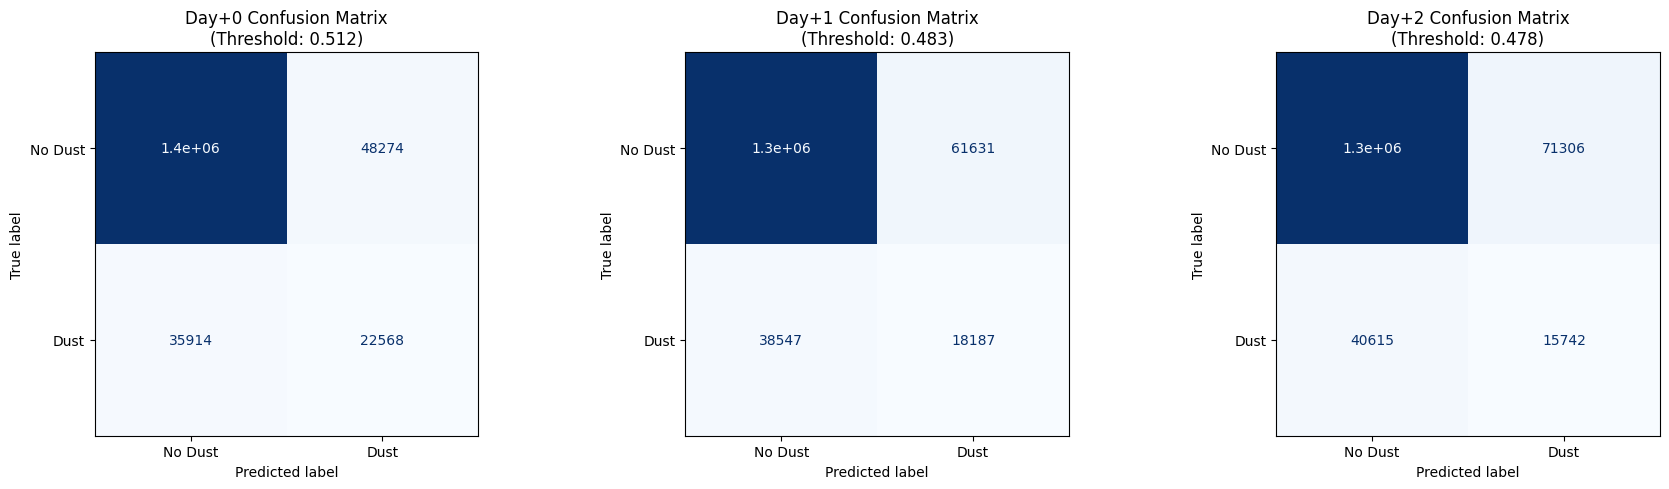


Saved optimized results to /kaggle/working/notebook_b/exp4_multihorizon_results_optimized.pkl


In [22]:
from sklearn.metrics import (
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score, 
    average_precision_score, accuracy_score
)
import matplotlib.pyplot as plt
import pickle
import numpy as np
import torch

mh_model.eval()
vp0, vp1, vp2, vt0, vt1, vt2 = [], [], [], [], [], []

print("Running validation inference...")
with torch.no_grad():
    for atm, surf, y in val_loader_multi:
        atm = atm.to(device, non_blocking=True)
        surf = surf.to(device, non_blocking=True)
        
        with torch.cuda.amp.autocast():
            logits = mh_model(atm, surf)
            
        probs = torch.sigmoid(logits).cpu().numpy()
        y_np = y.numpy()
        vp0.extend(probs[:, 0]); vp1.extend(probs[:, 1]); vp2.extend(probs[:, 2])
        vt0.extend(y_np[:, 0]); vt1.extend(y_np[:, 1]); vt2.extend(y_np[:, 2])

# Helper function to find the optimal F1 threshold
def find_optimal_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), 
                          out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
    optimal_idx = np.argmax(f1_scores)
    opt_thresh = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]
    return opt_thresh, f1_scores[optimal_idx]

results_exp4 = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, probs, trues, key) in enumerate([('Day+0', vp0, vt0, 'day0'), ('Day+1', vp1, vt1, 'day1'), ('Day+2', vp2, vt2, 'day2')]):
    probs = np.array(probs)
    trues = np.array(trues)
    
    # Dynamically find the best decision threshold
    opt_thresh, best_f1 = find_optimal_threshold(trues, probs)
    preds = (probs > opt_thresh).astype(int)
    
    # Calculate all metrics
    opt_prec = precision_score(trues, preds, zero_division=0)
    opt_rec = recall_score(trues, preds, zero_division=0)
    acc = accuracy_score(trues, preds)
    roc_auc = roc_auc_score(trues, probs)
    pr_auc = average_precision_score(trues, probs)
    
    print(f"\n{name} (Evaluated at Calibrated Threshold: {opt_thresh:.4f}):")
    print(f"  Precision: {opt_prec:.4f}")
    print(f"  Recall:    {opt_rec:.4f}")
    print(f"  F1 Score:  {best_f1:.4f}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    print(f"  PR-AUC:    {pr_auc:.4f}")
    
    # Generate and plot Confusion Matrix
    cm = confusion_matrix(trues, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dust', 'Dust'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f"{name} Confusion Matrix\n(Threshold: {opt_thresh:.3f})")
    
    results_exp4[key] = {
        'threshold': opt_thresh, 'precision': opt_prec, 'recall': opt_rec,
        'f1': best_f1, 'accuracy': acc, 'roc_auc': roc_auc, 'pr_auc': pr_auc
    }

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/figures/confusion_matrices.png')
plt.show()

with open(f'{SAVE_DIR}/exp4_multihorizon_results_optimized.pkl', 'wb') as f:
    pickle.dump(results_exp4, f)
print(f"\nSaved optimized results to {SAVE_DIR}/exp4_multihorizon_results_optimized.pkl")

### Visual Diagnostics

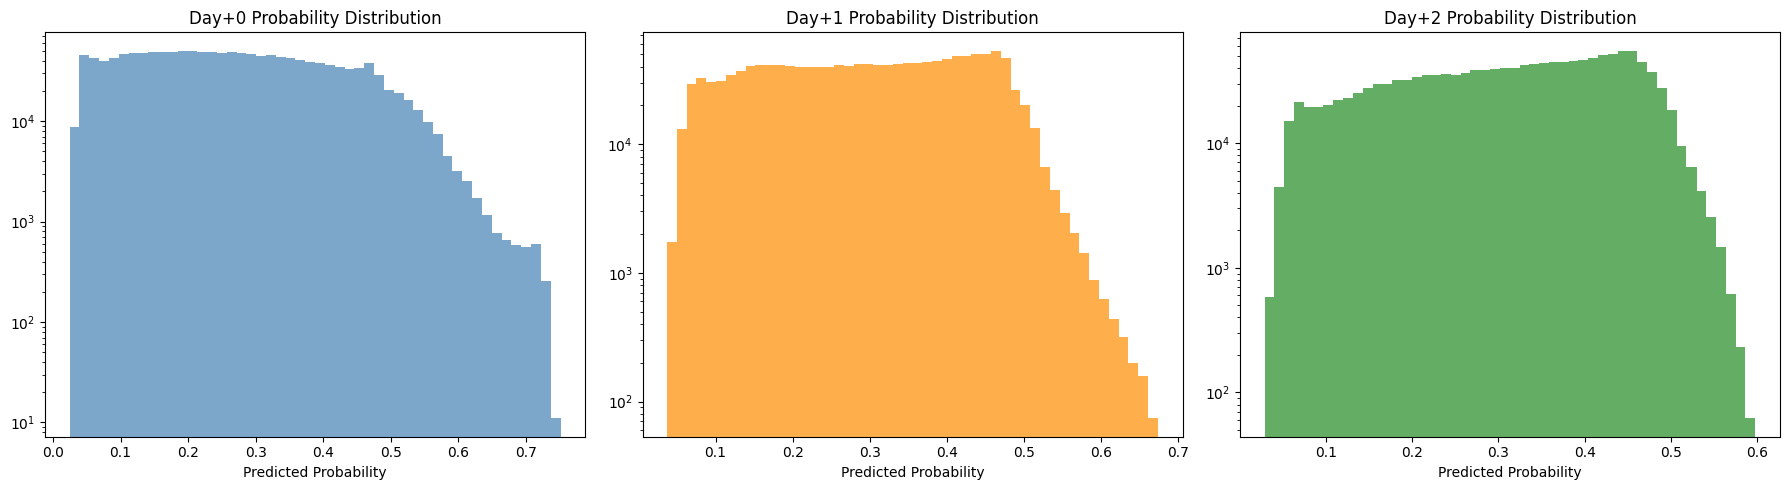

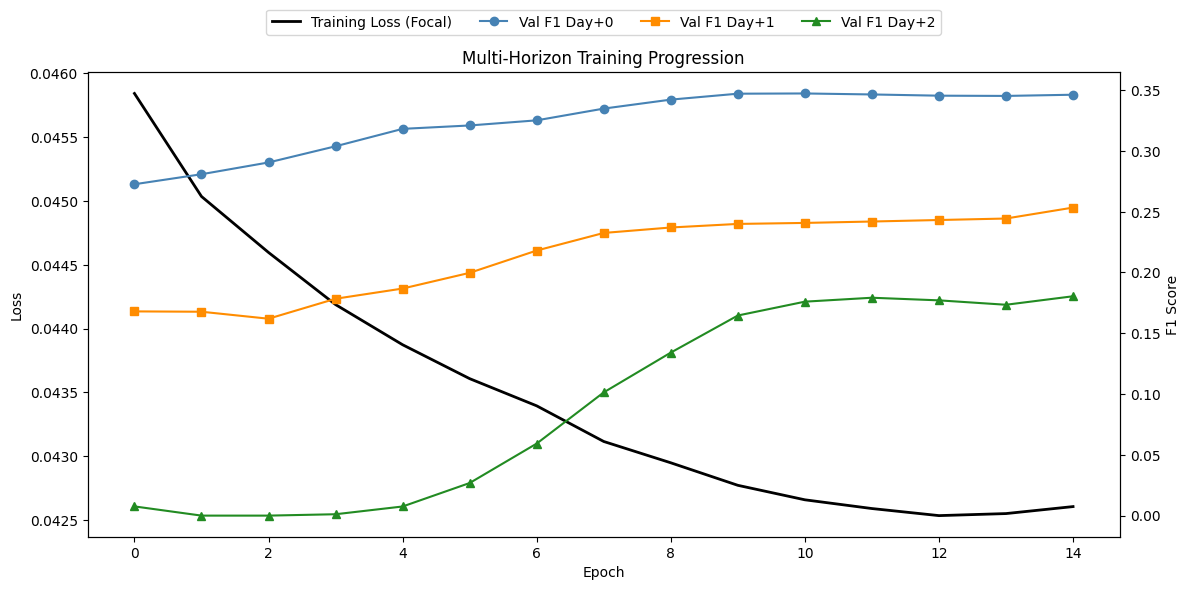

In [23]:
import glob
import os

def plot_multihorizon_diagnostics(save_dir, vp0, vp1, vp2):
    """
    Visualizes raw probability distributions and training history, loading the most
    recent checkpoint dynamically from the specified path.
    """
    # Plot 1: Raw Probability Distributions
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].hist(vp0, bins=50, alpha=0.7, color='steelblue')
    axes[0].set_title("Day+0 Probability Distribution")
    axes[0].set_xlabel("Predicted Probability")
    axes[0].set_yscale('log') # Log scale helps see the rare positive probabilities
    
    axes[1].hist(vp1, bins=50, alpha=0.7, color='darkorange')
    axes[1].set_title("Day+1 Probability Distribution")
    axes[1].set_xlabel("Predicted Probability")
    axes[1].set_yscale('log')
    
    axes[2].hist(vp2, bins=50, alpha=0.7, color='forestgreen')
    axes[2].set_title("Day+2 Probability Distribution")
    axes[2].set_xlabel("Predicted Probability")
    axes[2].set_yscale('log')
    
    plt.tight_layout()
    os.makedirs(os.path.join(save_dir, 'figures'), exist_ok=True)
    plt.savefig(os.path.join(save_dir, 'figures', 'probability_distributions.png'))
    plt.show()

    # Dynamic file path resolution for the most recent checkpoint
    checkpoint_search_path = os.path.join(save_dir, 'models', '*checkpoint*.pt')
    checkpoint_files = glob.glob(checkpoint_search_path)
    
    if checkpoint_files:
        latest_ckpt_path = max(checkpoint_files, key=os.path.getctime)
        ckpt_data = torch.load(latest_ckpt_path, map_location='cpu')
        history = ckpt_data.get('history')
        
        if history and 'train_loss' in history:
            # Plot 2: Training Curves (Loss vs F1 Scores)
            fig, ax1 = plt.subplots(figsize=(12, 6))
            
            ax1.plot(history['train_loss'], label='Training Loss (Focal)', color='black', linewidth=2)
            ax1.set_xlabel('Epoch')
            ax1.set_ylabel('Loss', color='black')
            ax1.tick_params(axis='y', labelcolor='black')
            
            ax2 = ax1.twinx()
            ax2.plot(history['val_f1_day0'], label='Val F1 Day+0', color='steelblue', marker='o')
            ax2.plot(history['val_f1_day1'], label='Val F1 Day+1', color='darkorange', marker='s')
            ax2.plot(history['val_f1_day2'], label='Val F1 Day+2', color='forestgreen', marker='^')
            ax2.set_ylabel('F1 Score')
            
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)
            
            plt.title('Multi-Horizon Training Progression')
            plt.tight_layout()
            plt.savefig(os.path.join(save_dir, 'figures', 'training_curves.png'))
            plt.show()
        else:
            print("No valid history found in the checkpoint.")
    else:
        print("No checkpoint files found to plot training curves.")

# Execute the diagnostic plot
plot_multihorizon_diagnostics(SAVE_DIR, vp0, vp1, vp2)